initialization: 0.100 final validation error:  0.24142719572837704
initialization: 0.030 final validation error:  0.031139606797053243
initialization: 0.010 final validation error:  0.0044944557778014245


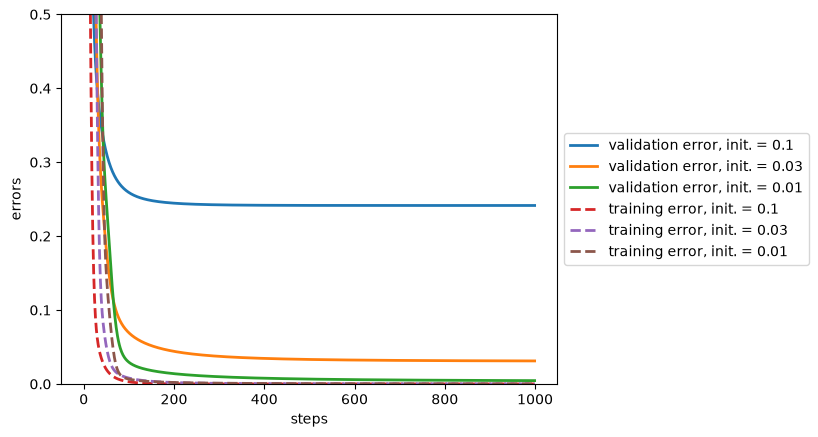

batchsize:  1 final validation error:  0.06774947147327173
batchsize:  5 final validation error:  0.21841554905117203
batchsize:  40 final validation error:  0.24142719572837718


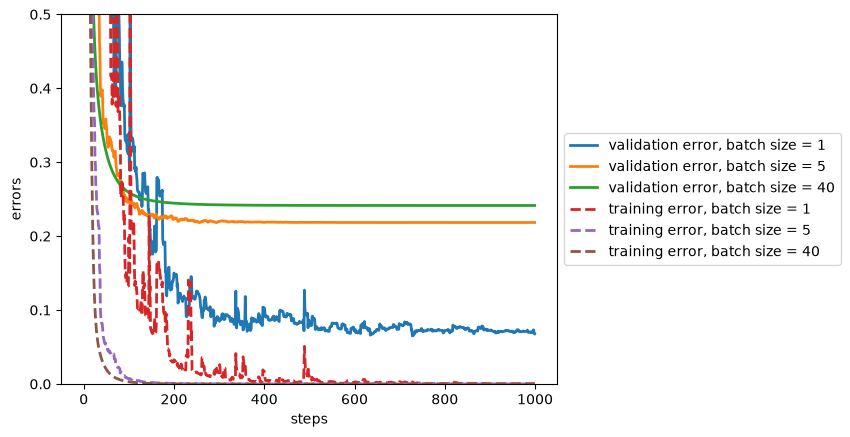

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import util

# 二次参数化模型
class QP:
    def __init__(self, dim, beta = None):
        self.dim = dim
        if beta is None:
            self.theta = np.ones(dim)
            self.phi = np.ones(dim)
        else:
            self.theta = beta.copy()
            self.phi = beta.copy()
            
    def train_GD(self, X, Y, eta = 8e-2, max_step = 1000, 
                 verbose = False, X_val = None, Y_val = None):
        """使用梯度下降训练二次参数化模型

        参数：
            X: 形状为 (n, d) 的输入矩阵
            Y: 形状为 (n,) 的标签向量
            eta: 学习率
            max_step: 最大训练步数
            verbose: 是否记录并返回训练集和验证集的误差日志
            X_val: 验证集输入
            Y_val: 验证集标签
        """
        if verbose:
            log_steps = []
            log_vals = []
            log_trains = []

        for t in range(max_step):
            # *** 在此开始编写代码 ***
            gradient_theta,gradient_phi=self.gradient(X,Y)
            self.theta=self.theta - eta * gradient_theta
            self.phi=self.phi - eta * gradient_phi
            # *** 代码编写结束 ***
            if verbose:
                log_steps.append(t)
                log_vals.append(self.validation(X_val, Y_val))
                log_trains.append(self.validation(X, Y))
                
        if verbose:
            return (log_steps, log_trains, log_vals)
            
    def train_SGD(self, X, Y, eta = 8e-2, max_step = 1000, batch_size = 1, 
                  verbose = False, X_val = None, Y_val = None):
        """使用随机梯度下降训练二次参数化模型

        参数：
            X: 形状为 (n, d) 的输入矩阵
            Y: 形状为 (n,) 的标签向量
            eta: 学习率
            max_step: 最大训练步数
            batch_size: 随机梯度下降每批使用的样本数
            verbose: 是否记录并返回训练集和验证集的误差日志
            X_val: 验证集输入
            Y_val: 验证集标签
        """
        if verbose:
            log_steps = []
            log_vals = []
            log_trains = []

        np.random.seed(0)
        n = X.shape[0]
        idx = np.arange(n)

        for t in range(max_step):
            idx_batch = np.random.choice(idx, size = batch_size, replace = False)
            X_batch = X[idx_batch]
            Y_batch = Y[idx_batch]

            # *** 在此开始编写代码 ***
            gradient_theta,gradient_phi=self.gradient(X_batch,Y_batch)
            self.theta=self.theta - eta * gradient_theta
            self.phi=self.phi - eta * gradient_phi
            # *** 代码编写结束 ***
            if verbose:
                log_steps.append(t)
                log_vals.append(self.validation(X_val, Y_val))
                log_trains.append(self.validation(X, Y))
        if verbose:
            return (log_steps, log_trains, log_vals)
    
    def predict(self, X):
        return X.dot(self.theta ** 2 - self.phi ** 2)
    
    def gradient(self, X, Y):
        """返回损失函数关于 theta 和 phi 的梯度
        """
        # 计算梯度的各个分量
        # *** 在此开始编写代码 ***
        gradient_theta=0
        gradient_phi=0
        n=len(X)
        for i in range(n):
            gradient_theta+=(X[i].T @ (self.theta ** 2 -self.phi ** 2) - Y[i]) \
            * (util.new_operation_character(self.theta,X[i]))

            gradient_phi-=(X[i].T @ (self.theta ** 2 -self.phi ** 2) - Y[i])   \
            * (util.new_operation_character(self.phi,X[i]))

        return gradient_theta / n , gradient_phi / n
        # *** 代码编写结束 ***
    
    def validation(self, X, Y):
        return np.average(0.25 * (self.predict(X) - Y) ** 2)

def QP_model_initialization(train_path, valid_path):
    X, Y = util.load_dataset(train_path)
    X_val, Y_val = util.load_dataset(valid_path)
    d = X.shape[1]
    
    save_path = "implicitreg_quadratic_initialization"

    # 使用不同的初始值，通过梯度下降训练二次参数化模型。
    # 在同一张图中绘制不同初始值下的验证误差曲线，
    # 横轴为梯度更新步数。
    log = []
    labels = []
    alphas = [0.1, 0.03, 0.01]
    for i in range(len(alphas)):
        alpha = alphas[i]
        model = QP(d, np.ones(d) * alpha)
        log.append(model.train_GD(X, Y, verbose = True, X_val = X_val, Y_val = Y_val))
        labels.append("init. = {}".format(alphas[i]))
        print("initialization: {:.3f}".format(alpha), "final validation error: ", model.validation(X_val, Y_val))
    util.plot_training_and_validation_curves(log, save_path, label = labels)

def QP_model_batchsize(train_path, valid_path):
    X, Y = util.load_dataset(train_path)
    X_val, Y_val = util.load_dataset(valid_path)
    d = X.shape[1]
    
    save_path = "implicitreg_quadratic_batchsize"

    # 使用不同的批大小，通过随机梯度下降训练二次参数化模型。
    # 在同一张图中绘制不同批大小下的验证误差曲线，
    # 横轴为梯度更新步数。
    log = []
    labels = []
    bs = [1, 5, 40]
    for i in range(len(bs)):
        model = QP(d, np.ones(d) * 0.1)
        log.append(model.train_SGD(X, Y, eta = 0.08, batch_size = bs[i], verbose = True, 
                        X_val = X_val, Y_val = Y_val))
        labels.append("batch size = {}".format(bs[i]))
        print("batchsize: ", bs[i], "final validation error: ", model.validation(X_val, Y_val))
    util.plot_training_and_validation_curves(log, save_path, label = labels)

def implicitreg_main():
    train_path = 'ds2_train.csv'
    valid_path = 'ds2_valid.csv'
    QP_model_initialization(train_path, valid_path)
    QP_model_batchsize(train_path, valid_path)

if __name__ == '__main__':
    implicitreg_main()